### Complex analysis

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


import numpy as np

import re



from collections import Counter



import networkx as nx

import colorsys
import pygraphviz as pgv
from networkx.drawing.nx_agraph import to_agraph




# Set PDF font type for Illustrator compatibility
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)
plt.rcParams['ps.fonttype'] = 42   # For saving as EPS too, if needed

### Loading the interaction files with p values

In [7]:
pvalues_shuffle = pd.read_csv("/project/GCRB/Hon_lab/s438217/cNMF/TF_full/TF_full_cNMF_figure_2_plots/random_shuffle_pvalue.csv")


In [8]:


pvalues_shuffle["fold_change"] = pvalues_shuffle["Observed Count"]/pvalues_shuffle["Mean Null Count"]
pvalues_shuffle.set_index("Unnamed: 0",inplace=True)


In [9]:
# Apply regex to clean '-P1', '-P2', or '-P1P2' only at the end of each gene name
pvalues_shuffle['Gene_1_Clean'] = pvalues_shuffle['Gene 1'].str.replace(r'-P[12](P2)?$', '', regex=True)
pvalues_shuffle['Gene_2_Clean'] = pvalues_shuffle['Gene 2'].str.replace(r'-P[12](P2)?$', '', regex=True)

# Create cleaned pair label
pvalues_shuffle['Pair_Clean'] = pvalues_shuffle['Gene_1_Clean'] + ' - ' + pvalues_shuffle['Gene_2_Clean']


In [10]:
filtered_pvalues_shuffle = pvalues_shuffle[pvalues_shuffle["Adjusted P Value"]<0.05]



In [13]:
filtered_pvalues_shuffle = filtered_pvalues_shuffle[filtered_pvalues_shuffle['Mean Null Count'] < filtered_pvalues_shuffle['Observed Count']]
filtered_pvalues_shuffle = filtered_pvalues_shuffle[filtered_pvalues_shuffle['Observed Count'] != filtered_pvalues_shuffle['Mean Null Count']]
filtered_pvalues_shuffle = filtered_pvalues_shuffle[filtered_pvalues_shuffle['Observed Count'] >2]



## Figure 2K - volcano plots for the interacting pairs

/home2/s438217/.conda/envs/new_scanpy/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


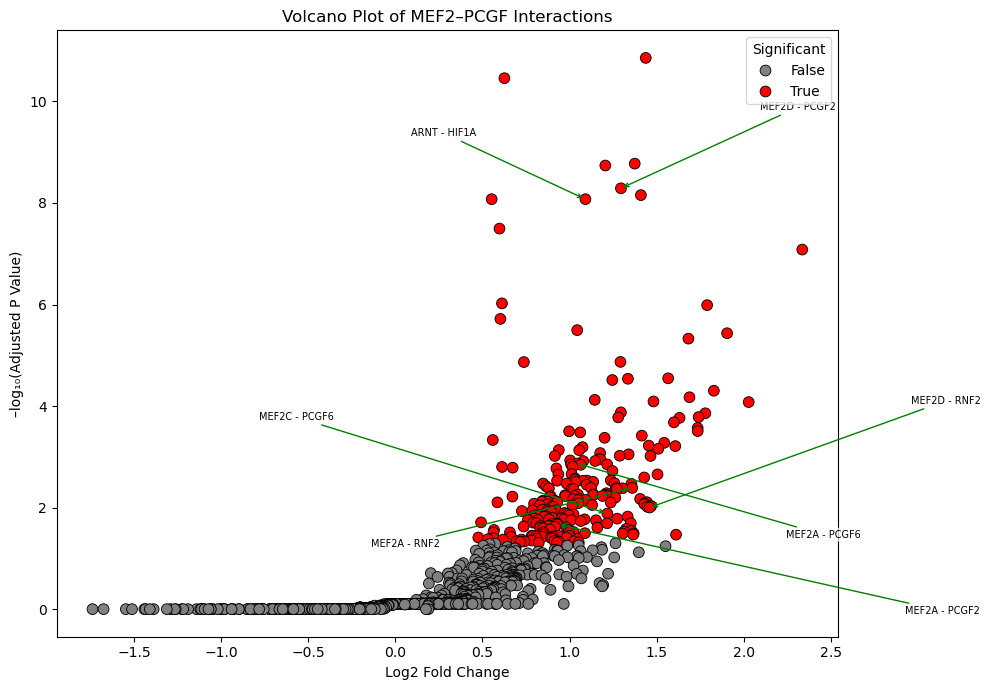

In [22]:

# Copy dataframe and drop NaNs
volcano_df = pvalues_shuffle.dropna(subset=['Adjusted P Value', 'fold_change']).copy()

# Compute log2 fold change, avoid log2(0)
volcano_df['log2FC'] = np.log2(volcano_df['fold_change'].replace(0, np.nan))

volcano_df = volcano_df[volcano_df['Observed Count'] >2]

# Clean gene names
volcano_df['Gene 1 Clean'] = volcano_df['Gene 1'].str.replace(r'-P[12](P2)?$', '', regex=True)
volcano_df['Gene 2 Clean'] = volcano_df['Gene 2'].str.replace(r'-P[12](P2)?$', '', regex=True)
volcano_df['Pair_Clean'] = volcano_df['Gene 1 Clean'] + ' - ' + volcano_df['Gene 2 Clean']

# Compute -log10 adjusted p-value
volcano_df['-log10pval'] = -np.log10(volcano_df['Adjusted P Value'])

# Define significance threshold
volcano_df['Significant'] = volcano_df['Adjusted P Value'] < 0.05

# List of cleaned pairs to annotate
annotate_pairs = [
    'MEF2A - PCGF2',
    'ARNT - HIF1A',
    'MEF2A - PCGF6',
    'MEF2A - RNF2',
    'MEF2C - PCGF6',
    'MEF2C - RNF2',
    'MEF2D - PCGF2',
    'MEF2D - RNF2'
]

# Define varied offsets for label positioning
offsets = [(0.8, 1.5), (-1.0, 1.2), (1.2, -1.5), (-1.5, -1.2), (1.5, 2), (-2, 1.8), (2, -1.8), (-2.5, 1)]

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=volcano_df,
    x='log2FC',
    y='-log10pval',
    hue='Significant',
    palette={True: 'red', False: 'grey'},
    edgecolor='black',
    s=60
)

# Annotate selected pairs with arrows
annotated_count = 0
for _, row in volcano_df.iterrows():
    if row['Pair_Clean'] in annotate_pairs:
        dx, dy = offsets[annotated_count % len(offsets)]
        plt.annotate(
            row['Pair_Clean'],
            xy=(row['log2FC'], row['-log10pval']),
            xytext=(row['log2FC'] + dx, row['-log10pval'] + dy),
            arrowprops=dict(arrowstyle='->', color='green', lw=1),
            fontsize=7,
            ha='left',
            va='bottom',
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
        )
        annotated_count += 1

# Aesthetics
plt.xlabel('Log2 Fold Change')
plt.ylabel('–log₁₀(Adjusted P Value)')
plt.title('Volcano Plot of MEF2–PCGF Interactions')
plt.legend(title='Significant', loc='upper right')
plt.tight_layout()
#plt.savefig("/project/GCRB/Hon_lab/s438217/cNMF/TF_full/TF_full_cNMF_figure_2_plots/complex_analysis_volcano_plot_greater_than_2.pdf")
plt.show()


In [11]:
mask = (volcano_df['log2FC'] >= 0.8) & (volcano_df['log2FC'] <= 1)
subset = volcano_df.loc[mask]


In [12]:
sig = volcano_df[volcano_df["Observed Count"]>2]

In [13]:
sig = sig[sig["Adjusted P Value"]<0.05]

## Plotting the PCGF2/6/RNF2 counts

In [14]:


def plot_gene_interaction_bargraph(df, target_genes, top_n=10, label_genes=None):
    """
    Plots a histogram showing how many target genes each gene interacts with.
    
    Parameters:
    - df (DataFrame): DataFrame with columns ['Gene 1', 'Gene 2', 'Observed Count']
    - target_genes (list): List of target genes to check interactions with
    - top_n (int): Number of top interacting genes to label (ignored if label_genes is provided)
    - label_genes (list or None): List of gene prefixes to label (matches genes starting with these prefixes)
    
    Returns:
    - fig, ax: Matplotlib figure and axis objects
    """

    def starts_with_any(gene, prefix_list):
        """Helper function to check if a gene starts with any string in prefix_list."""
        return any(gene.startswith(prefix) for prefix in prefix_list)

    # Dictionary to store interaction sets for each gene
    interaction_map = {}

    # Filter rows where either Gene 1 or Gene 2 starts with a target gene
    filtered_df = df[df['Gene 1'].apply(lambda g: starts_with_any(g, target_genes)) | 
                      df['Gene 2'].apply(lambda g: starts_with_any(g, target_genes))]

    for _, row in filtered_df.iterrows():
        gene1, gene2 = row['Gene 1'], row['Gene 2']

        if starts_with_any(gene1, target_genes):
            interaction_map.setdefault(gene2, set()).add(gene1)
        if starts_with_any(gene2, target_genes):
            interaction_map.setdefault(gene1, set()).add(gene2)

    # Convert dictionary to DataFrame
    interaction_df = pd.DataFrame([(gene, len(targets), tuple(sorted(targets))) 
                                   for gene, targets in interaction_map.items()], 
                                  columns=['Gene', 'Interaction Count', 'Target Interactions'])

    # Keep only genes that interact with at least 2 target genes
    interaction_df = interaction_df[interaction_df['Interaction Count'] >= 2]

    # If empty, print a message and return None
    if interaction_df.empty:
        print("No genes interact with at least 2 target genes.")
        return None, None

    # Sort the DataFrame
    interaction_df = interaction_df.sort_values(by=['Interaction Count', 'Target Interactions', 'Gene'], 
                                                ascending=[False, True, True])

    # Decide which genes to label
    if label_genes:
        genes_to_label = {gene for gene in interaction_df['Gene'] if starts_with_any(gene, label_genes)}
    else:
        genes_to_label = set(interaction_df.head(top_n)['Gene'])  # Default to top_n genes

    # Assign colors
    colors = interaction_df['Interaction Count'].map(lambda x: 'dodgerblue' if x == 3 else 'lightcoral')

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(20, 10))
    bars = ax.bar(interaction_df['Gene'], interaction_df['Interaction Count'], color=colors, edgecolor='black')

    # Annotate bars with target gene interactions
    for bar, (gene, count, targets) in zip(bars, zip(interaction_df['Gene'], interaction_df['Interaction Count'], interaction_df['Target Interactions'])):
        if count == 2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"({', '.join(targets)})",
                    ha='center', va='bottom', fontsize=7, color='black', fontweight='bold', rotation=90)

    # Set x-axis labels as gene names
    ax.set_xticks(range(len(interaction_df)))
    ax.set_xticklabels(interaction_df['Gene'], rotation=90, fontsize=5)

    ax.set_ylabel("Number of Target Genes Interacted With", fontsize=12)
    ax.set_title("TF Interactions with Target Genes", fontsize=14)

    return fig, ax,interaction_df  # Return figure and axis objects


## Figure 2M - Common programs between pairs 

#### Loading the file that has program number for each interaction

In [37]:
df_merged = pd.read_csv('/project/GCRB/Hon_lab/s438217/cNMF/TF_full/gene_program_interactions_with_program_number.csv')

In [38]:
df_merged = df_merged.drop(columns=["Unnamed: 0.1", "Unnamed: 0"], errors='ignore')

In [17]:
df_merged = df_merged[df_merged['Adjusted P Value']<0.05]

In [18]:
df_merged = df_merged[df_merged["Observed Count"]>1]

### HIF1A ARNT programs

In [19]:
df_merged[(df_merged["Gene 1"].str.startswith("ARNT")) & (df_merged["Gene 2"].str.startswith("HIF1A"))]["Common_Programs"].to_list()


['[2, 135, 10, 145, 21, 24, 27, 29, 158, 31, 161, 36, 40, 44, 178, 50, 53, 56, 186, 192, 67, 73, 201, 80, 209, 83, 104, 236, 123]']

## MEF2A

In [20]:

target_genes = ["PCGF2", "PCGF6", "RNF2"]

target_genes = tuple(target_genes)

In [21]:
df_mef2a = df_merged[df_merged["Gene 1"].str.startswith("MEF2A") | df_merged["Gene 2"].str.startswith("MEF2A")]

df_links = df_mef2a[
    df_mef2a["Gene 1"].str.startswith(target_genes) | df_mef2a["Gene 2"].str.startswith(target_genes)
]


In [22]:
df_links

,Gene 1,Gene 2,Observed Count,Mean Null Count,P Value,Adjusted P Value,fold change,clean_gene1,clean_gene2,Interaction Type (BioGrid),Common_Programs
1157,MEF2A-P1P2,PCGF6-P1P2,3,1.455988,0.000219,0.001355,2.060456,MEF2A,PCGF6,No interaction found,"[8, 1, 28]"
1223,MEF2A-P1P2,RNF2-P1P2,3,1.168860,0.000699,0.004088,2.566604,MEF2A,RNF2,No interaction found,"[1, 4, 5]"
1424,MEF2A-P1P2,PCGF2-P1,3,1.576419,0.004267,0.021421,1.903047,MEF2A,PCGF2,No interaction found,"[1, 4, 5]"


## MEF2C

In [23]:
df_mef2c = df_merged[df_merged["Gene 1"].str.startswith("MEF2C") | df_merged["Gene 2"].str.startswith("MEF2C")]

df_link_mef2c = df_mef2c[
    df_mef2c["Gene 1"].str.startswith(target_genes) | df_mef2c["Gene 2"].str.startswith(target_genes)
]


In [24]:
df_link_mef2c = df_link_mef2c[["Gene 1","Gene 2","Common_Programs"]]

In [25]:
df_link_mef2c

,Gene 1,Gene 2,Common_Programs
1347,MEF2C-P1P2,PCGF6-P1P2,"[1, 8, 9, 26, 28]"
1414,MEF2C-P1P2,RNF2-P1P2,"[1, 5]"


## MEF2D

In [26]:
df_mef2d = df_merged[df_merged["Gene 1"].str.startswith("MEF2D") | df_merged["Gene 2"].str.startswith("MEF2D")]

df_link_mef2d = df_mef2d[
    df_mef2d["Gene 1"].str.startswith(target_genes) | df_mef2d["Gene 2"].str.startswith(target_genes)
]


In [53]:
df_link_mef2d

,Gene 1,Gene 2,Observed Count,Mean Null Count,P Value,Adjusted P Value,fold change,clean_gene1,clean_gene2,Interaction Type (BioGrid),Common_Programs
71,MEF2D-P1P2,PCGF2-P1,3,1.222458,5.170000e-11,5.140000e-09,2.454073,MEF2D,PCGF2,No interaction found,"[1, 4, 5]"
1321,MEF2D-P1P2,RNF2-P1P2,3,1.090566,1.840233e-03,9.958418e-03,2.750865,MEF2D,RNF2,No interaction found,"[1, 4, 5]"


### Finding interactions of TBX5 and GATA4

In [52]:
df_merged

,Gene 1,Gene 2,Observed Count,Mean Null Count,P Value,Adjusted P Value,fold change,clean_gene1,clean_gene2,Interaction Type (BioGrid),Common_Programs
0,HAND2-P1,ZSCAN10-P1P2,2,1.025641,0.000000,0.0,1.950000,HAND2,ZSCAN10,No interaction found,"[1, 4]"
1,BBX-P1P2,MSX2-P1P2,2,1.013793,0.000000,0.0,1.972789,BBX,MSX2,No interaction found,"[5, 7]"
2,ADNP2-P1P2,BHLHA15-P1P2,8,2.236324,0.000000,0.0,3.577299,ADNP2,BHLHA15,No interaction found,"[133, 39, 111, 113, 51, 245, 87, 59]"
3,ATMIN-P1P2,TEAD4-P1P2,5,1.457187,0.000000,0.0,3.431270,ATMIN,TEAD4,No interaction found,"[39, 111, 113, 245, 59]"
4,TBX5-P2,ZC3H15-P1P2,2,1.040698,0.000000,0.0,1.921788,TBX5,ZC3H15,No interaction found,"[9, 12]"
...,...,...,...,...,...,...,...,...,...,...,...
7149,ZNF311-P1P2,ZNF462-P1P2,1,1.029412,0.998124,1.0,0.971429,ZNF311,ZNF462,No interaction found,[39]
7150,TAF12-P1P2,ZNF18-P1P2,1,1.022222,1.000000,1.0,0.978261,TAF12,ZNF18,No interaction found,[11]
7151,TCF4-P1P2,ZIC2-P1P2,1,1.011765,1.000000,1.0,0.988372,TCF4,ZIC2,No interaction found,[12]
7152,DNAJC19,FOXP4-P1P2,1,1.037383,0.999548,1.0,0.963964,DNAJC19,FOXP4,No interaction found,[80]


In [39]:
df_TBX5 = df_merged[df_merged["Gene 1"].str.startswith("TBX5") | df_merged["Gene 2"].str.startswith("TBX5")]


In [40]:
df_TBX5["Interaction Type (BioGrid)"].value_counts()

Interaction Type (BioGrid)
No interaction found                      61
psi-mi:"MI:0915"(physical association)     5
psi-mi:"MI:0407"(direct interaction)       1
Name: count, dtype: int64

In [41]:
df_TBX5.sort_values(by = "Adjusted P Value")

,Gene 1,Gene 2,Observed Count,Mean Null Count,P Value,Adjusted P Value,fold change,clean_gene1,clean_gene2,Interaction Type (BioGrid),Common_Programs
4,TBX5-P2,ZC3H15-P1P2,2,1.040698,0.000000e+00,0.000000e+00,1.921788,TBX5,ZC3H15,No interaction found,"[9, 12]"
7,FOXD3-P1,TBX5-P2,2,1.026667,0.000000e+00,0.000000e+00,1.948052,FOXD3,TBX5,No interaction found,"[3, 12]"
20,TBX5-P2,TCF4-P1P2,2,1.017045,0.000000e+00,0.000000e+00,1.966480,TBX5,TCF4,No interaction found,"[12, 23]"
64,KLF12-P1P2,TBX5-P2,2,1.073059,1.310000e-11,1.440000e-09,1.863830,KLF12,TBX5,No interaction found,"[12, 23]"
65,SMAD2-P1P2,TBX5-P2,2,1.076923,1.350000e-11,1.460000e-09,1.857143,SMAD2,TBX5,No interaction found,"[9, 12]"
...,...,...,...,...,...,...,...,...,...,...,...
7040,TBX5-P2,ZIC2-P1P2,1,1.033557,1.000000e+00,1.000000e+00,0.967532,TBX5,ZIC2,No interaction found,[12]
7057,TBX5-P2,YWHAE-P1P2,1,1.044872,9.997441e-01,1.000000e+00,0.957055,TBX5,YWHAE,No interaction found,[12]
7078,ARID4B-P1P2,TBX5-P2,1,1.084112,9.999937e-01,1.000000e+00,0.922414,ARID4B,TBX5,No interaction found,[3]
7086,TBX5-P2,ZNF384-P1P2,1,1.041026,9.999999e-01,1.000000e+00,0.960591,TBX5,ZNF384,No interaction found,[3]


In [44]:
df_TBX5[df_TBX5["Interaction Type (BioGrid)"]!="No interaction found"]

,Gene 1,Gene 2,Observed Count,Mean Null Count,P Value,Adjusted P Value,fold change,clean_gene1,clean_gene2,Interaction Type (BioGrid),Common_Programs
1187,GATA4-P1P2,TBX5-P2,4,1.485714,0.000423,0.002547,2.692308,GATA4,TBX5,"psi-mi:""MI:0915""(physical association)","[9, 3, 12, 23]"
1402,MTF2-P1P2,TBX5-P2,2,1.163462,0.003594,0.018325,1.719008,MTF2,TBX5,"psi-mi:""MI:0915""(physical association)","[9, 12]"
1456,MEIS1-P1P2,TBX5-P2,2,1.345955,0.005772,0.028343,1.485934,MEIS1,TBX5,"psi-mi:""MI:0915""(physical association)","[9, 3]"
1914,TBX5-P2,TP53-P1P2,2,1.672589,0.063161,0.235954,1.195751,TBX5,TP53,"psi-mi:""MI:0915""(physical association)","[3, 23]"
4223,GATA6-P1P2,TBX5-P2,1,1.000000,0.500340,0.787220,1.000000,GATA6,TBX5,"psi-mi:""MI:0915""(physical association)",[23]
5835,NKX2-5-P1P2,TBX5-P2,1,2.083064,0.999774,1.000000,0.480062,NKX2-5,TBX5,"psi-mi:""MI:0407""(direct interaction)",[23]


In [45]:
df_GATA4 = df_merged[df_merged["Gene 1"].str.startswith("GATA4") | df_merged["Gene 2"].str.startswith("GATA4")]


In [47]:
df_GATA4[df_GATA4["Interaction Type (BioGrid)"]!="No interaction found"]

,Gene 1,Gene 2,Observed Count,Mean Null Count,P Value,Adjusted P Value,fold change,clean_gene1,clean_gene2,Interaction Type (BioGrid),Common_Programs
1187,GATA4-P1P2,TBX5-P2,4,1.485714,0.000423,0.002547,2.692308,GATA4,TBX5,"psi-mi:""MI:0915""(physical association)","[9, 3, 12, 23]"
1642,GATA4-P1P2,GTF2I-P1P2,3,1.858469,0.016468,0.071704,1.614232,GATA4,GTF2I,"psi-mi:""MI:0915""(physical association)","[18, 12, 28]"
1694,GATA4-P1P2,TP53-P1P2,7,3.892137,0.021408,0.090356,1.798498,GATA4,TP53,"psi-mi:""MI:0915""(physical association)","[1, 3, 36, 39, 13, 78, 23]"
1743,GATA4-P1P2,TBX20-P1P2,9,5.476000,0.026810,0.109883,1.643535,GATA4,TBX20,"psi-mi:""MI:0915""(physical association)","[1, 3, 36, 9, 12, 78, 23, 26, 28]"
1779,BCLAF1-P1P2,GATA4-P1P2,2,1.108179,0.030843,0.124060,1.804762,BCLAF1,GATA4,"psi-mi:""MI:0915""(physical association)","[3, 39]"
1819,GATA4-P1P2,KMT2A-P1P2,3,2.183130,0.038067,0.149633,1.374174,GATA4,KMT2A,"psi-mi:""MI:0915""(physical association)","[3, 13, 247]"
1880,GATA4-P1P2,GATAD1-P1P2,2,1.819712,0.054134,0.205889,1.099075,GATA4,GATAD1,"psi-mi:""MI:0915""(physical association)","[12, 39]"
1924,GATA4-P1P2,ZFPM2-P1P2,6,2.861254,0.066568,0.247389,2.096983,GATA4,ZFPM2,"psi-mi:""MI:0915""(physical association)","[162, 36, 12, 78, 18, 28]"
1944,GATA4-P1P2,ZNF787-P1P2,2,1.937644,0.072537,0.266800,1.032181,GATA4,ZNF787,"psi-mi:""MI:0915""(physical association)","[1, 39]"
2279,ADNP2-P1P2,GATA4-P1P2,3,3.000000,0.495087,0.787220,1.000000,ADNP2,GATA4,"psi-mi:""MI:0915""(physical association)","[113, 36, 39]"


In [51]:
df_merged[df_merged["Gene 1"].str.startswith("NPAC") | df_merged["Gene 2"].str.startswith("NPAC")]

,Gene 1,Gene 2,Observed Count,Mean Null Count,P Value,Adjusted P Value,fold change,clean_gene1,clean_gene2,Interaction Type (BioGrid),Common_Programs


### Gene program terms for in the interactors

In [59]:
prog_num = [8, 28, 1, 4, 5, 9, 26]

In [60]:
GO = pd.read_csv("/project/GCRB/Hon_lab/s438217/cNMF/TF_full/TF_perturb_full/Gene_ontology_K_250.csv")

In [61]:
GO = GO[GO["Adjusted P-value"]<0.05]

In [63]:
complex_programs = GO[GO["Source"].isin(prog_num)]

In [67]:
complex_programs = (
    complex_programs
    .groupby("Source", group_keys=False)   # replace "number" with your group column name
    .apply(lambda x: x.sort_values(by="Adjusted P-value"))
)


/tmp/ipykernel_27934/338627062.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values(by="Adjusted P-value"))


In [69]:
complex_programs["Source"].value_counts()

Source
26    282
1     205
8     181
5     144
28    134
9     111
4      73
Name: count, dtype: int64

In [89]:
complex_programs[complex_programs["Program number"]==4]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Genes,Program number
612,GO_Biological_Process_2023,Cellular Respiration (GO:0045333),30/85,1.766584e-33,2.644576e-30,COX7B;NDUFA13;NDUFB8;NDUFB7;NDUFA11;UQCRB;NDUF...,4
613,GO_Biological_Process_2023,Mitochondrial ATP Synthesis Coupled Electron T...,28/70,3.783126e-33,2.831670e-30,COX7B;NDUFB8;NDUFB7;UQCRB;NDUFA12;COX4I1;NDUFB...,4
614,GO_Biological_Process_2023,Aerobic Electron Transport Chain (GO:0019646),27/68,6.821576e-32,3.403967e-29,COX7B;NDUFB8;NDUFB7;UQCRB;COX4I1;NDUFB3;NDUFB2...,4
615,GO_Molecular_Function_2023,Oxidoreduction-Driven Active Transmembrane Tra...,23/54,3.424750e-28,9.623548e-26,COX8A;COX7B;NDUFB8;NDUFA7;NDUFB7;UQCRB;NDUFA12...,4
616,GO_Biological_Process_2023,Oxidative Phosphorylation (GO:0006119),22/63,1.044810e-24,3.910200e-22,ATP5PF;NDUFA13;NDUFB8;NDUFA7;NDUFB7;ATP5PD;NDU...,4
...,...,...,...,...,...,...,...
680,GO_Cellular_Component_2023,Sarcoplasmic Reticulum Membrane (GO:0033017),3/27,7.487352e-03,4.318167e-02,JPH2;DMPK;ATP2A2,4
681,GO_Cellular_Component_2023,Sarcolemma (GO:0042383),4/52,7.634329e-03,4.318167e-02,POPDC2;ATP1A1;FLNC;AQP1,4
682,GO_Cellular_Component_2023,U12-type Spliceosomal Complex (GO:0005689),3/28,8.294073e-03,4.549174e-02,SNRPD2;SNRPG;SNRPF,4
683,GO_Cellular_Component_2023,Vesicle (GO:0031982),9/235,9.285809e-03,4.802090e-02,MYL6;CD81;APOA1;CALM3;ATP1A2;ATP1A1;MFGE8;TUBB...,4


In [82]:
complex_programs = complex_programs[["Gene_set","Term","Overlap","P-value","Adjusted P-value","Genes","Source"]]

In [84]:
complex_programs = complex_programs.rename(columns={"Source": "Program number"})


In [85]:
complex_programs

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Genes,Program number
0,GO_Biological_Process_2023,Cardiac Muscle Cell Development (GO:0055013),15/26,2.052729e-21,3.247418e-18,FHOD3;ADPRHL1;SORBS2;LRRC10;MYLK3;SLC8A1;TTN;C...,1
1,GO_Biological_Process_2023,Myofibril Assembly (GO:0030239),17/46,7.393806e-20,5.848501e-17,FHOD3;TMOD1;ADPRHL1;ACTN2;MYLK3;LMOD2;TTN;CSRP...,1
2,GO_Biological_Process_2023,Actomyosin Structure Organization (GO:0031032),20/77,1.201208e-19,6.334372e-17,FHOD3;TMOD1;MYH7B;ACTN2;MYLK3;LMOD2;TTN;CSRP3;...,1
3,GO_Biological_Process_2023,Striated Muscle Contraction (GO:0006941),17/57,5.089455e-18,2.012879e-15,MYBPC3;RYR2;MYH7B;DTNA;SMPX;TNNC1;SLC8A1;TTN;M...,1
4,GO_Biological_Process_2023,Heart Contraction (GO:0060047),15/41,1.377732e-17,4.359145e-15,MYBPC3;RYR2;TNNC1;SLC8A1;TTN;TRDN;MYL4;CSRP3;A...,1
...,...,...,...,...,...,...,...
3825,GO_Biological_Process_2023,Positive Regulation Of Gene Expression (GO:001...,16/480,2.559293e-03,4.618144e-02,PTGER4;NIBAN1;APP;BMPR2;SLC24A3;FN1;TNC;ZNF804...,28
3826,GO_Biological_Process_2023,Enzyme-Linked Receptor Protein Signaling Pathw...,7/124,2.693458e-03,4.703299e-02,PDGFRB;BMPR2;FLT1;BDKRB2;TEK;IL6ST;ART4,28
3828,GO_Biological_Process_2023,Eye Morphogenesis (GO:0048592),3/19,2.709477e-03,4.703299e-02,COL5A1;COL5A2;FBN1,28
3827,GO_Biological_Process_2023,Positive Regulation Of Defense Response (GO:00...,7/124,2.693458e-03,4.703299e-02,PTGER4;APP;LGALS1;SERPINE1;CCN4;EMILIN1;ETS1,28


In [86]:
#complex_programs.to_csv("/project/GCRB/Hon_lab/s438217/cNMF/TF_full/TF_perturb_full/GO_terms_for_MEF2_PRC_interactions.csv")